In [1]:
import os
from datetime import datetime
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

os.makedirs("models", exist_ok=True)

def set_all_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)

seed = 0
set_all_seeds(seed)

In [ ]:
df = pd.read_csv(f"../BTCUSDT-1h-data.csv")
print(df)

       Unnamed: 0                  timestamp      open_time       open  \
0               0  2017-08-17 04:00:00+00:00  1502942400000    4261.48   
1               1  2017-08-17 05:00:00+00:00  1502946000000    4308.83   
2               2  2017-08-17 06:00:00+00:00  1502949600000    4330.29   
3               3  2017-08-17 07:00:00+00:00  1502953200000    4316.62   
4               4  2017-08-17 08:00:00+00:00  1502956800000    4333.32   
...           ...                        ...            ...        ...   
69079        8755  2025-07-09 19:00:00+00:00  1752087600000  109536.50   
69080        8756  2025-07-09 20:00:00+00:00  1752091200000  111749.99   
69081        8757  2025-07-09 21:00:00+00:00  1752094800000  110714.97   
69082        8758  2025-07-09 22:00:00+00:00  1752098400000  110818.36   
69083        8759  2025-07-09 23:00:00+00:00  1752102000000  111382.17   

            high        low      close       volume     close_time  \
0        4313.62    4261.32    4308.83   

**Check missing values**

In [3]:
print(df.isnull())
print(f"Counts how many missing values there are in each column: {df.isnull().sum()}")
print(f"Total missing values: {df.isnull().sum().sum()}")

       Unnamed: 0  timestamp  open_time   open   high    low  close  volume  \
0           False      False      False  False  False  False  False   False   
1           False      False      False  False  False  False  False   False   
2           False      False      False  False  False  False  False   False   
3           False      False      False  False  False  False  False   False   
4           False      False      False  False  False  False  False   False   
...           ...        ...        ...    ...    ...    ...    ...     ...   
69079       False      False      False  False  False  False  False   False   
69080       False      False      False  False  False  False  False   False   
69081       False      False      False  False  False  False  False   False   
69082       False      False      False  False  False  False  False   False   
69083       False      False      False  False  False  False  False   False   

       close_time  quote_av  trades  tb_base_av  tb

**Split data**

In [ ]:
train_end_idx = int(len(df) * 0.80)

df_train = df.iloc[:train_end_idx].copy()
df_test = df.iloc[train_end_idx:].copy()

df_test.reset_index(drop=True, inplace=True)

print(f"Length of df_train: {len(df_train)}")
print(f"Length of df_test: {len(df_test)}")

Length of df_train: 55267
Length of df_test: 13817


**Building Meaningful Features**

In [5]:
def build_features(opens, highs, lows, closes, volumes, train_scalers=None):

    # Build features
    feature1 = (closes - opens) / opens
    feature2 = (highs - opens) / opens
    feature3 = (highs - closes) / closes
    feature4 = (lows - opens) / opens
    feature5 = (lows - closes) / closes
    feature6 = (highs - lows) / opens
    feature7 = (highs - lows) / closes
    feature8 = volumes

    # Stack features
    features = [
        feature1,
        feature2,
        feature3,
        feature4,
        feature5,
        feature6,
        feature7,
        feature8,
    ]
    num_features = len(features)
    scaled_fts = []

    if train_scalers is None:
        train_scalers = [MaxAbsScaler() for _ in range(num_features)]
        is_train = True
    else:
        is_train = False

    for i in range(num_features):
        # Get train scaler
        scaler = train_scalers[i]
        if is_train:
            # Scaler -> Fit -> Train dataset
            scaled_ft = scaler.fit_transform(features[i].reshape(-1, 1))
            # Save the train scaler in a list
        elif not is_train:
            # Scaler -> NOT Fit -> Test dataset
            scaled_ft = scaler.transform(features[i].reshape(-1, 1))

        # Update list of SCALED features
        scaled_fts.append(scaled_ft.flatten())

    # Stack features
    scaled_features = np.stack(scaled_fts, axis=-1)

    # Get num. features
    num_features = scaled_features.shape[-1]
    return scaled_features, num_features, train_scalers

**Example of how the scaler works**

In [6]:
import numpy as np
from sklearn.preprocessing import MaxAbsScaler

# Suppose we have a simple 1D array (e.g. daily returns)
X = np.array([ -2, -1, 0, 1, 2 ])

print("Original data:", X)

# Step 1: reshape into 2D (because sklearn expects shape (n_samples, n_features))
X_2d = X.reshape(-1, 1)

# Step 2: create the scaler and fit_transform
scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X_2d)

# Step 3: flatten back to 1D for convenience
X_scaled = X_scaled.flatten()

print("Scaled data:", X_scaled)


Original data: [-2 -1  0  1  2]
Scaled data: [-1.  -0.5  0.   0.5  1. ]


**Preprocess data**

In [7]:
def preprocess_data(seq_len, df, train_scalers=None):
    m = len(df)

    opens = np.array(df['open'].values)
    highs = np.array(df['high'].values)
    lows = np.array(df['low'].values)
    closes = np.array(df['close'].values)
    volumes = np.array(df['volume'].values)

    # Build features
    features, num_features, train_scalers = build_features(opens, highs, lows, closes, volumes, train_scalers)

    # Calculate number of samples
    num_samples = m - seq_len

    # Create storage for inputs & targets
    X = np.zeros([num_samples, seq_len, num_features], dtype=np.float32)
    Y = np.zeros([num_samples, num_features], dtype=np.float32)

    # Create samples (X, Y)
    for i in range(num_samples):
        X[i] = features[i : i+seq_len]
        Y[i] = features[i+seq_len : i+seq_len+1]

    # Fix alignment
    opens = np.array(opens[seq_len:])
    closes = np.array(closes[seq_len:])

    return X, Y, num_features, opens, closes, train_scalers

In [ ]:
# Sequence Length
seq_len = 48

# Preprocess data
X_train, Y_train, num_features, _, _, train_scalers = preprocess_data(seq_len, df_train)
X_test, Y_test, num_features, backtest_opens, backtest_closes, _ = preprocess_data(seq_len, df_test, train_scalers)


In [9]:
m_train = X_train.shape[0]
m_test = X_test.shape[0]
print(f"m_train: {m_train}")
print(f"m_test: {m_test}")
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

m_train: 55219
m_test: 13769
X_train shape: (55219, 48, 8)
Y_train shape: (55219, 8)
X_test shape: (13769, 48, 8)
Y_test shape: (13769, 8)


**Transform data to Torch Tensor**

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else 'cpu')
print("my deive: ", device)

X_train = torch.from_numpy(X_train.astype(np.float32)).to(device, dtype=torch.float32)
Y_train = torch.from_numpy(Y_train.astype(np.float32)).to(device, dtype=torch.float32)

X_test = torch.from_numpy(X_test.astype(np.float32)).to(device, dtype=torch.float32)
Y_test = torch.from_numpy(Y_test.astype(np.float32)).to(device, dtype=torch.float32)

Y_pred_test = torch.zeros([m_test, num_features], device=device, dtype=torch.float32)

my deive:  cuda:0


**Build model**

In [11]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        # Conv1D
        self.conv1 = nn.Conv1d(
            in_channels=num_features,
            out_channels=64,
            kernel_size=3,
            padding=1,
            stride=1,
        )
        self.act1 = nn.GELU()

        # LSTM
        self.lstm = nn.LSTM(64, 32, batch_first=True)

        # Output layer
        self.fc_out = nn.Linear(32, num_features)

    def forward(self, x):
        # Conv1D
        x = x.permute(0, 2, 1) # (batch, num_features, seq_len)
        x = self.conv1(x)
        x = self.act1(x)
        x = x.permute(0, 2, 1) # (batch, seq_len, num_features)

        # LSTM
        x, (h_n, c_n) = self.lstm(x)
        x = x[:, -1, :]

        # Output layer
        x = self.fc_out(x)
        return x



**Initialization**

In [12]:
# Initialize model
model = Model()

# Transfer model to device
model.to(device)

# Initialize criterion
criterion = nn.MSELoss()

# Choose learning rate
lr = 1e-4

# Create optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Choose batch size
batch_size = 32

# Lists of train/test losses
train_losses = []
test_losses = []

equity_epochs = []
accuracy_epochs = []

# Set epoch
num_epochs = 1000



In [13]:
def create_minibatches(X, Y, batch_size, seed, shuffle=True):

    mini_batches = []
    m = len(X)
    if shuffle:
        permutation = list(np.random.permutation(m))
        X = X[permutation]
        Y = Y[permutation]
    num_batches = m // batch_size
    for k in range(num_batches):
        mb_X = X[k * batch_size : k * batch_size + batch_size]
        mb_Y = Y[k * batch_size : k * batch_size + batch_size]
        mb_pair = (mb_X, mb_Y)
        mini_batches.append(mb_pair)

    seed += 1
    set_all_seeds(seed)

    return mini_batches, seed

**Load model (if available)**

In [14]:
def load_training_data(model, optimizer):
    checkpoint = torch.load('training_process', weights_only=False)
    epoch = checkpoint['epoch']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']
    equity_epochs = checkpoint['equity_epochs']
    accuracy_epochs = checkpoint['accuracy_epochs']
    seed = checkpoint['seed']

    # Load model's weights & optimizer's state
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    return model, optimizer, epoch, train_losses, test_losses, equity_epochs, accuracy_epochs, seed


if os.path.exists("training_process"):
    model, optimizer, epoch, train_losses, test_losses, equity_epochs, accuracy_epochs, seed = load_training_data(model, optimizer)
    print(f"Loaded model!")
else:
    print(f"No training process to load.")
    epoch = 0

Loaded model!


**Train model**

Epoch: 630, Equity: 2438.35, Accuracy: 51.05 train_losses: 0.0008588177507719619, test_losses: 0.00029788390384055674, Duration: 0:00:06.440661


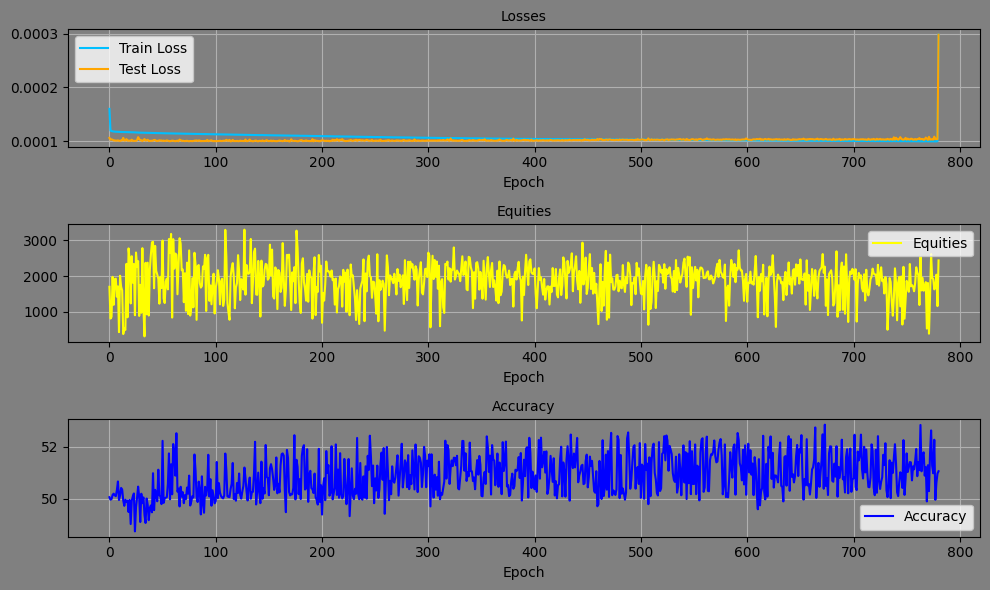

Epoch: 631, Equity: 2033.61, Accuracy: 50.80 train_losses: 0.0008044084650548715, test_losses: 0.00029941523098386824, Duration: 0:00:06.262312


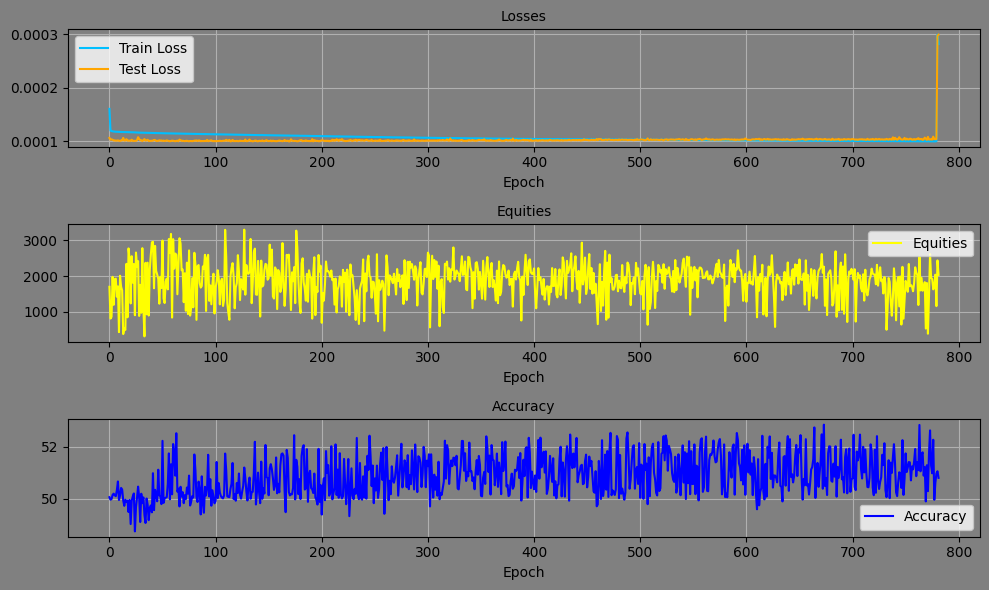

Epoch: 632, Equity: 2438.26, Accuracy: 50.46 train_losses: 0.0007824832818469209, test_losses: 0.0002969111083075404, Duration: 0:00:06.347917


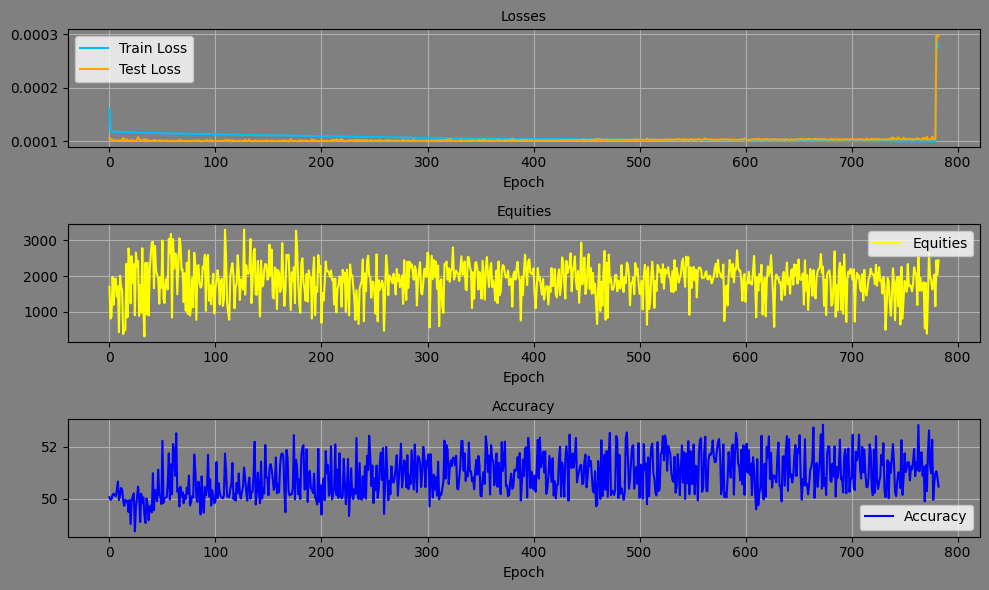

Epoch: 633, Equity: 2666.19, Accuracy: 50.40 train_losses: 0.0007678835939293714, test_losses: 0.00029657414415851235, Duration: 0:00:05.976101


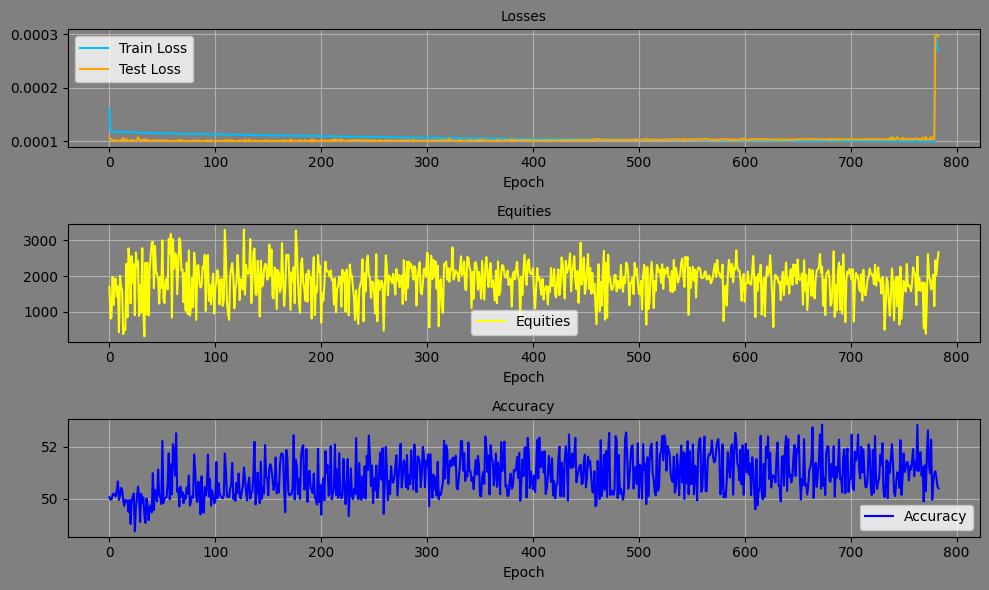

Epoch: 634, Equity: 3260.92, Accuracy: 50.90 train_losses: 0.0007566136840994105, test_losses: 0.0002981090219691396, Duration: 0:00:05.893430


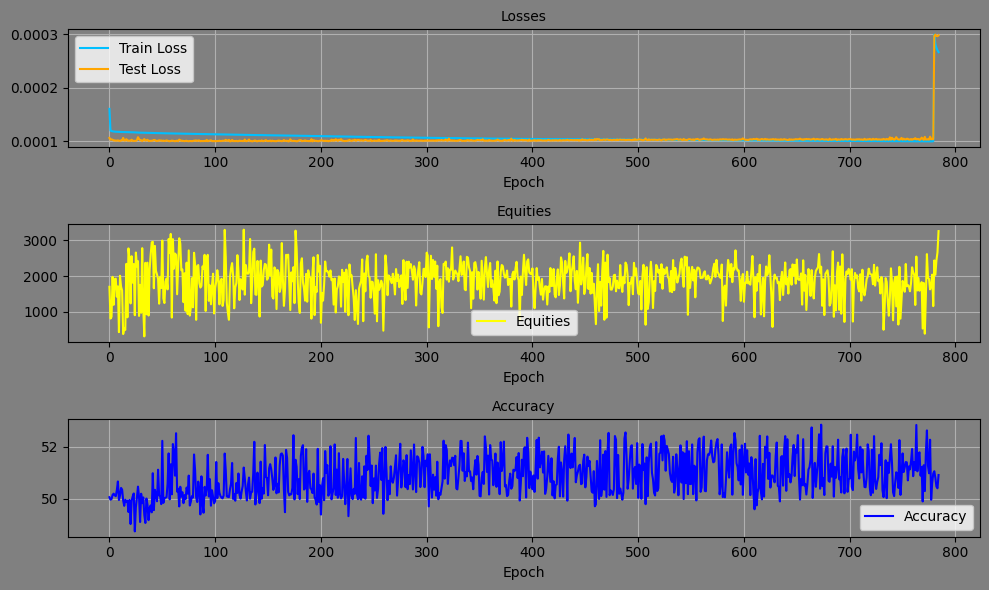

Epoch: 635, Equity: 1570.89, Accuracy: 50.66 train_losses: 0.0007445751566843103, test_losses: 0.00029692266252823174, Duration: 0:00:06.060666


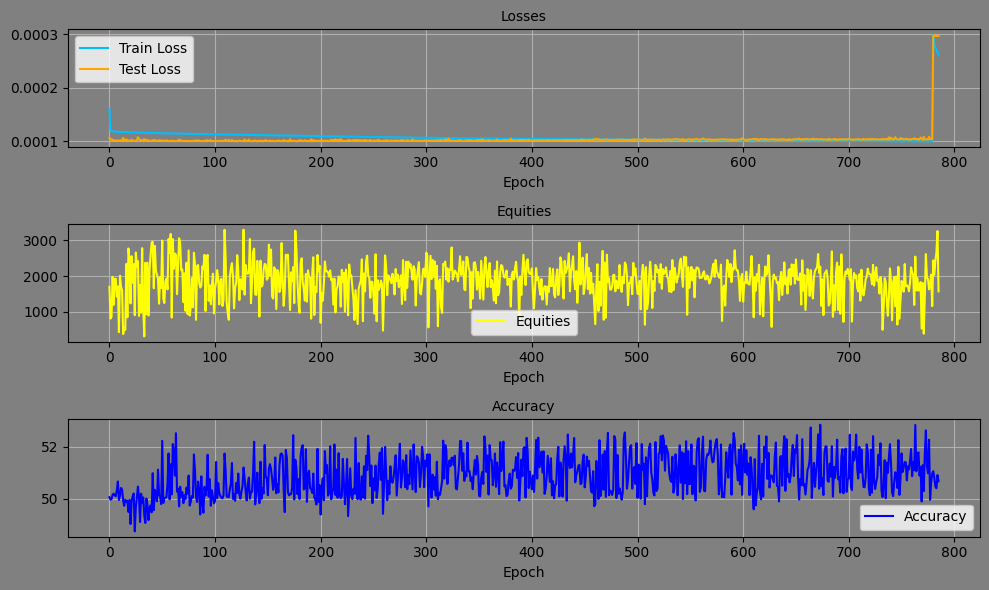

Epoch: 636, Equity: 2249.91, Accuracy: 50.64 train_losses: 0.0007397027517689149, test_losses: 0.00029771614936180413, Duration: 0:00:06.069727


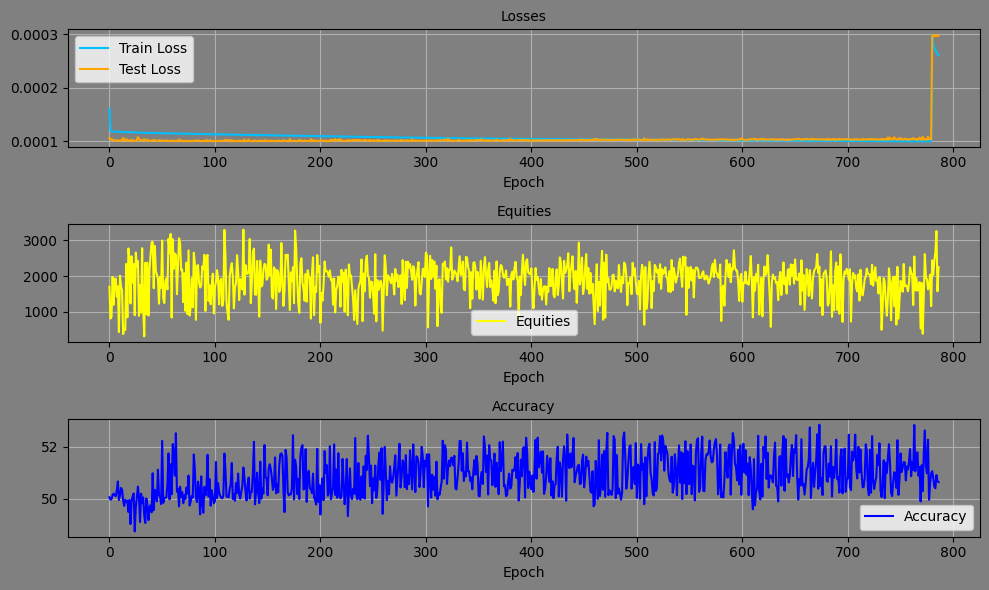

Epoch: 637, Equity: 2917.33, Accuracy: 51.27 train_losses: 0.0007336763967422472, test_losses: 0.0002971886715386063, Duration: 0:00:06.071009


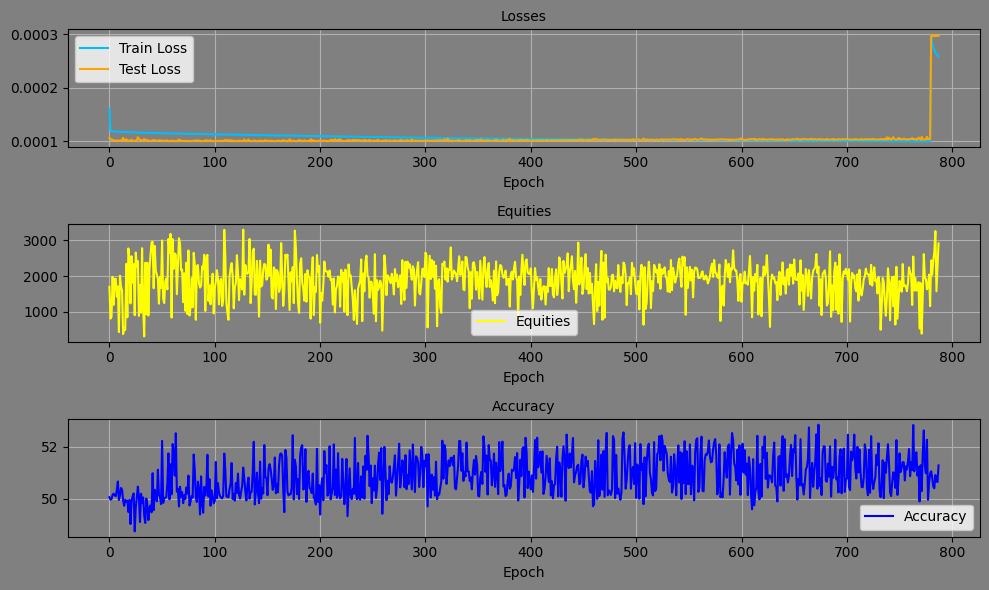

Epoch: 638, Equity: 2540.00, Accuracy: 50.37 train_losses: 0.000729117693347465, test_losses: 0.0002975689712911844, Duration: 0:00:05.812711


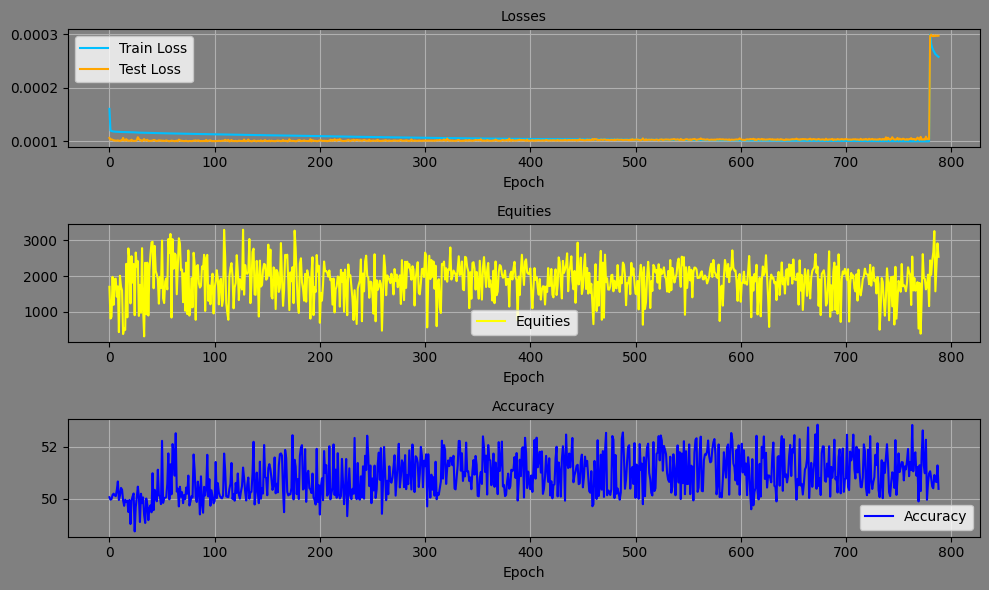

Epoch: 639, Equity: 2355.47, Accuracy: 50.21 train_losses: 0.0007237723589692589, test_losses: 0.00029804298537783325, Duration: 0:00:05.786933


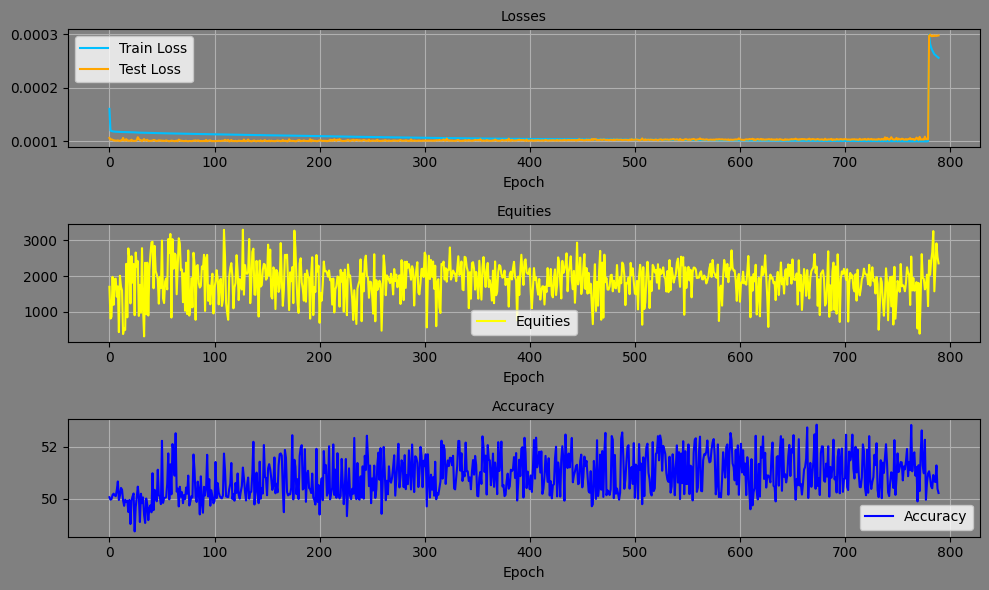

Epoch: 640, Equity: 2949.15, Accuracy: 52.08 train_losses: 0.0007205140300810445, test_losses: 0.0002976808464154601, Duration: 0:00:05.749148


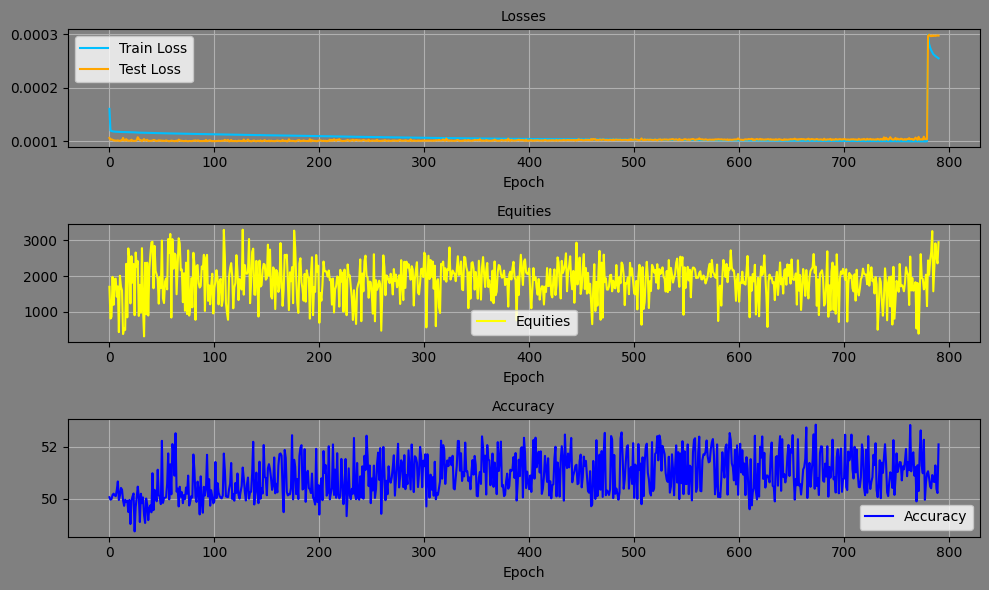

Epoch: 641, Equity: 2705.89, Accuracy: 50.93 train_losses: 0.0007170545608075201, test_losses: 0.00029751769034191966, Duration: 0:00:06.182973


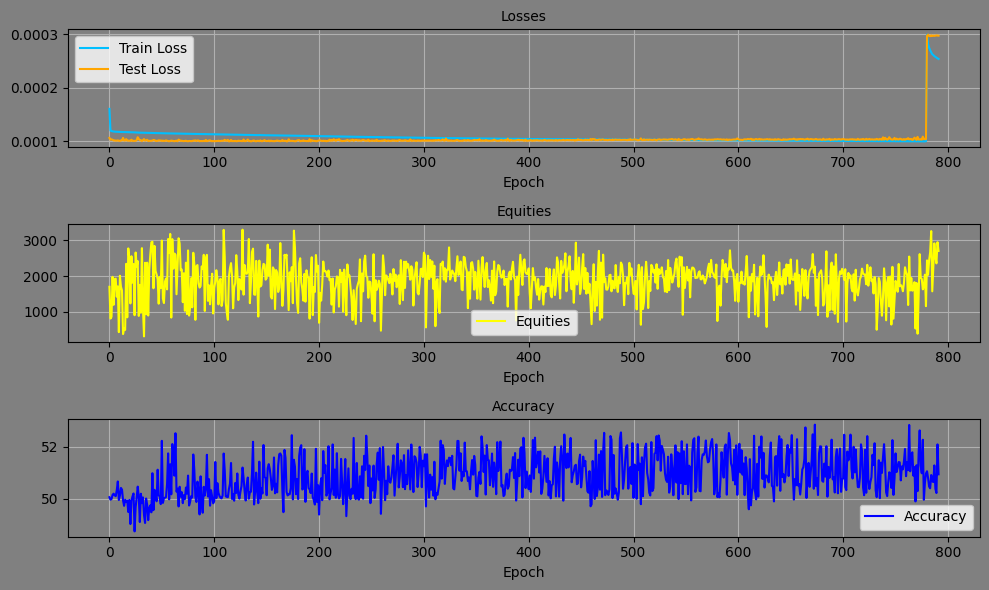

Epoch: 642, Equity: 2733.43, Accuracy: 50.96 train_losses: 0.0007129052813347105, test_losses: 0.00029884339892305434, Duration: 0:00:06.338711


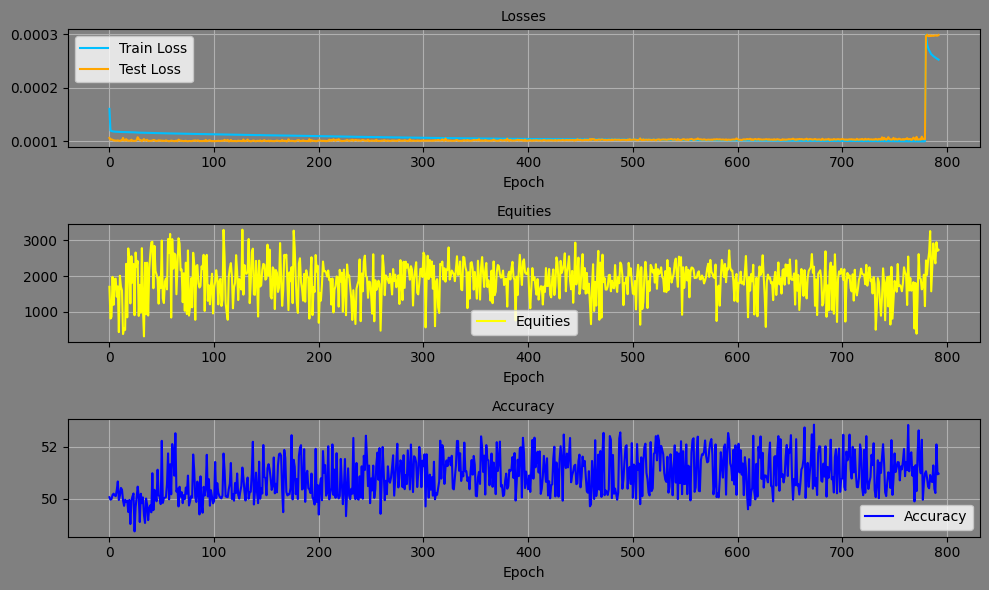

Epoch: 643, Equity: 2564.99, Accuracy: 51.84 train_losses: 0.0007099920995803415, test_losses: 0.00029751809779554605, Duration: 0:00:05.925270


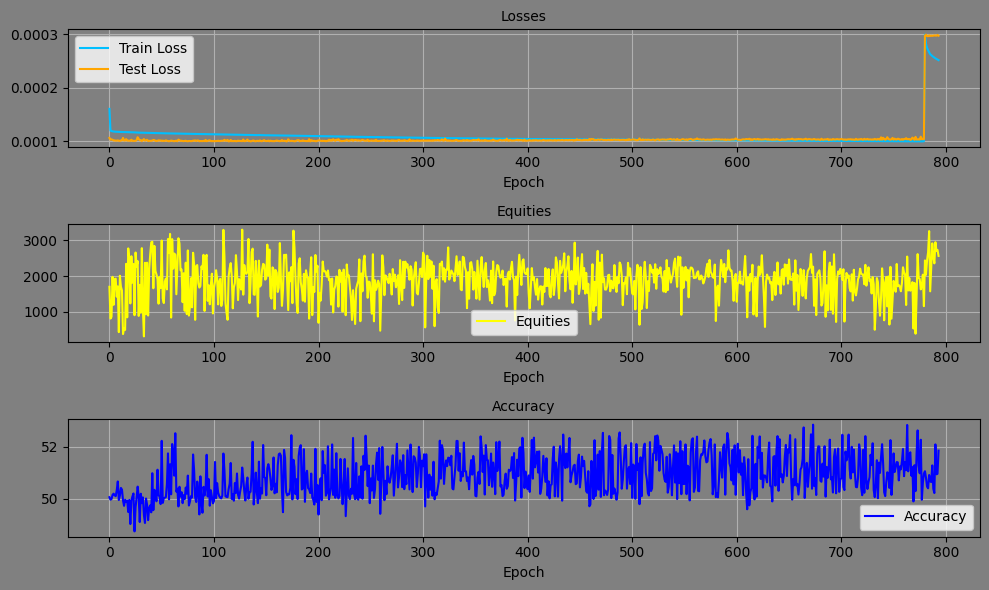

Epoch: 644, Equity: 3110.13, Accuracy: 51.86 train_losses: 0.0007079154898773582, test_losses: 0.0002975166717078537, Duration: 0:00:05.842883


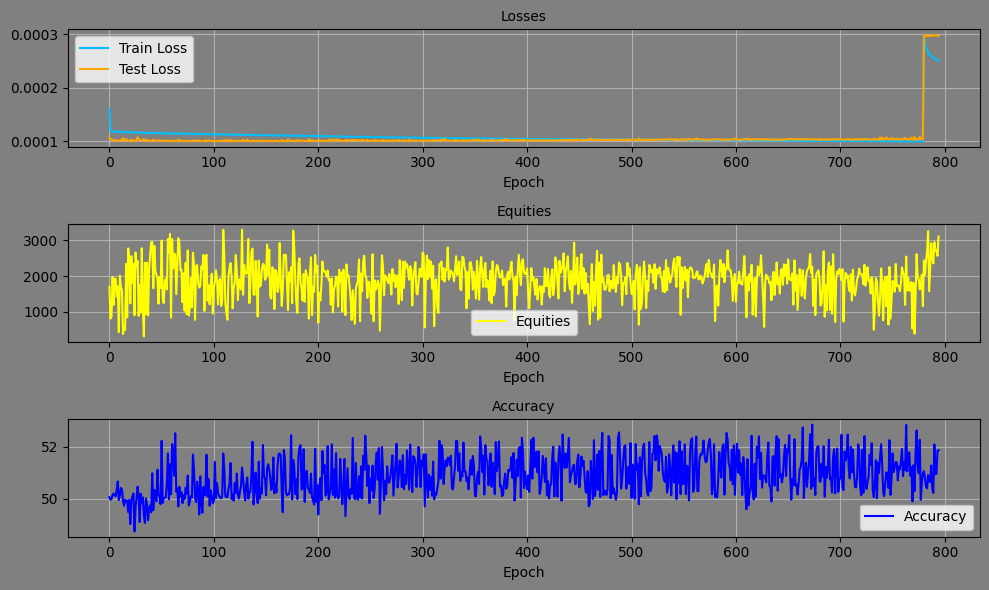

Epoch: 645, Equity: 3125.13, Accuracy: 51.11 train_losses: 0.0007046706455909863, test_losses: 0.00029745488427579403, Duration: 0:00:05.802859


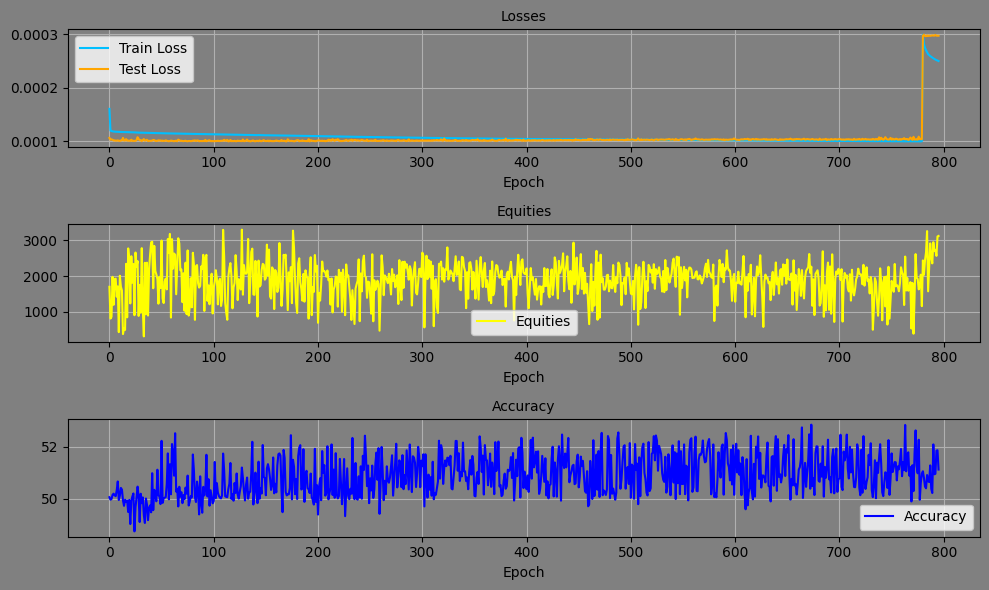

Epoch: 646, Equity: 2465.49, Accuracy: 50.79 train_losses: 0.0007029595291765029, test_losses: 0.0002972919028252363, Duration: 0:00:06.192558


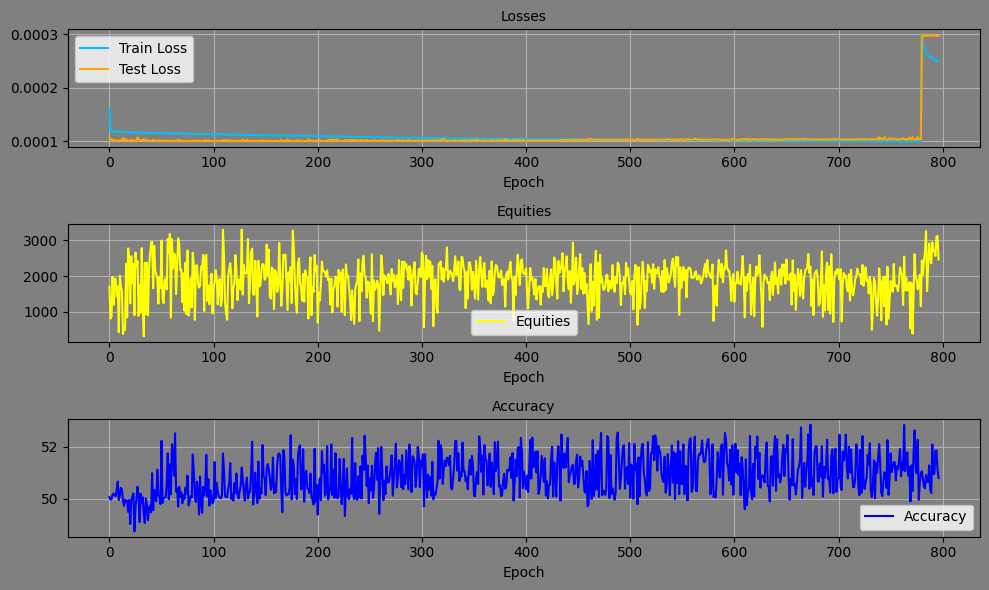

Epoch: 647, Equity: 3176.34, Accuracy: 51.35 train_losses: 0.0006997871507580082, test_losses: 0.00029797808383591473, Duration: 0:00:06.311543


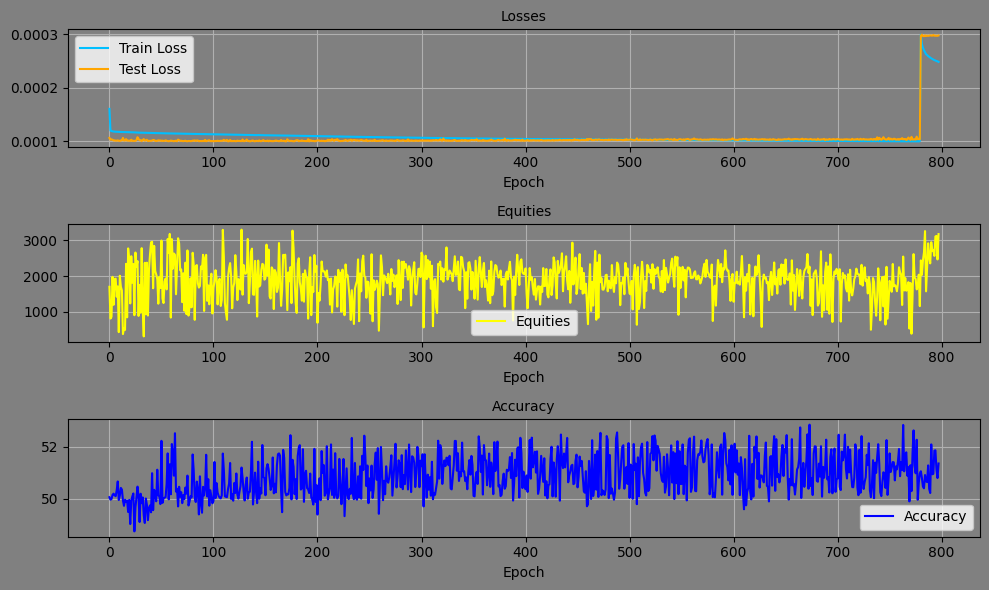

Epoch: 648, Equity: 2670.85, Accuracy: 52.02 train_losses: 0.0006970038509546388, test_losses: 0.00029763561906293035, Duration: 0:00:06.449884


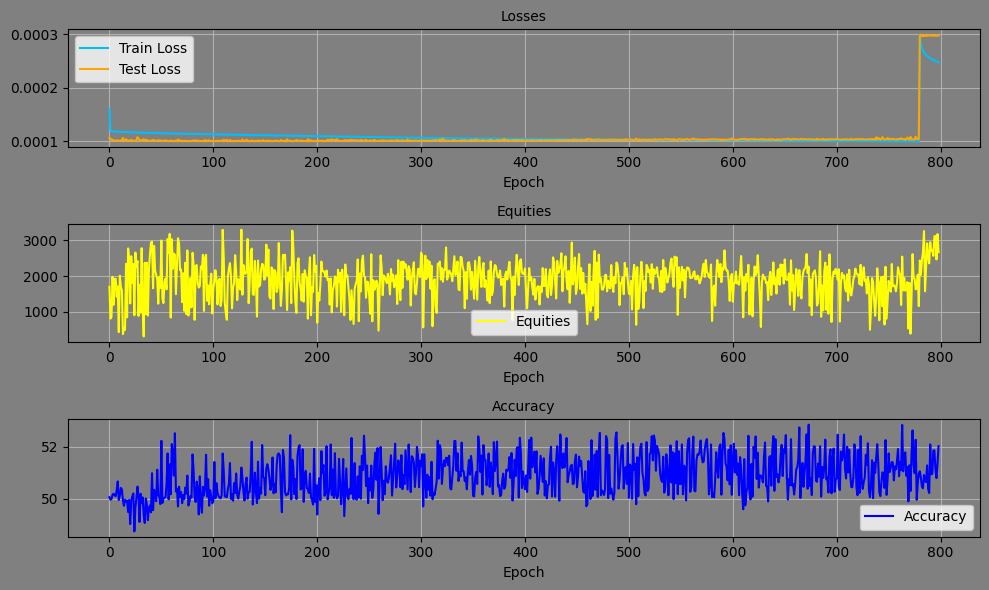

Epoch: 649, Equity: 2991.52, Accuracy: 51.53 train_losses: 0.0006955662398157047, test_losses: 0.00029871746664866805, Duration: 0:00:06.235007


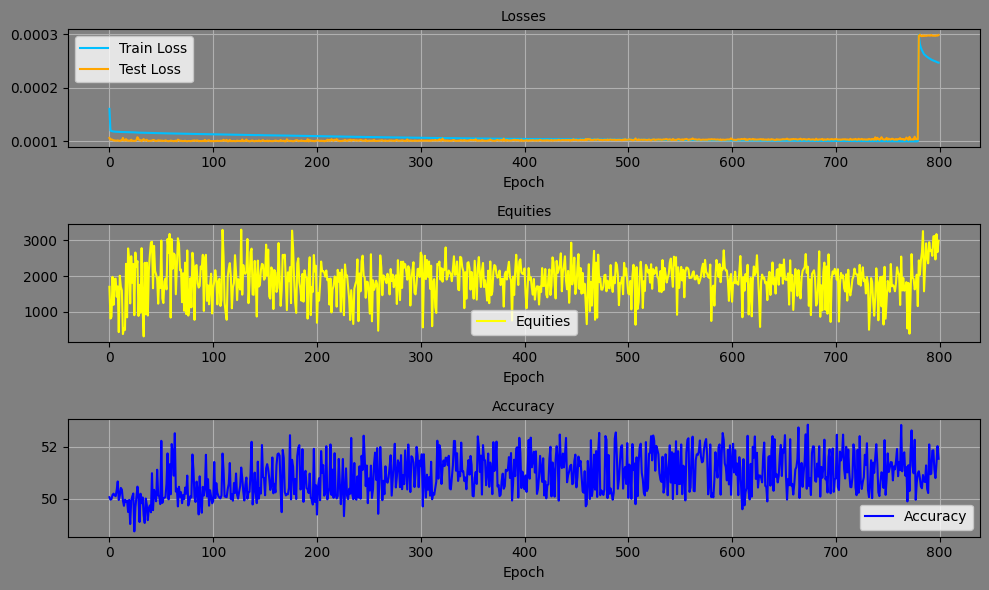

Epoch: 650, Equity: 2531.23, Accuracy: 51.25 train_losses: 0.0006931006901668034, test_losses: 0.000298450468108058, Duration: 0:00:05.987409


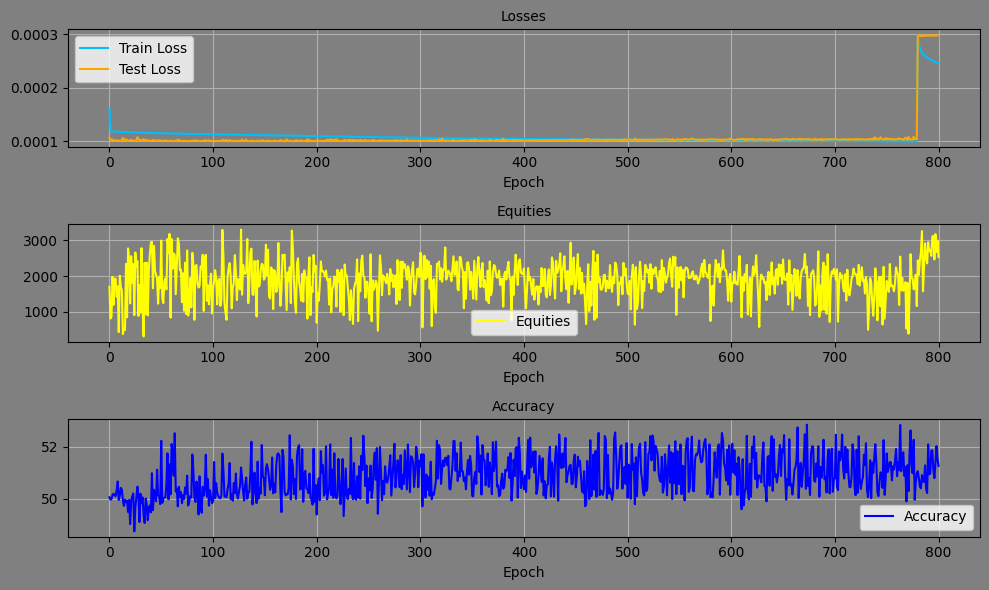

Epoch: 651, Equity: 1695.58, Accuracy: 51.18 train_losses: 0.0006918032286331004, test_losses: 0.0002985315804835409, Duration: 0:00:06.455088


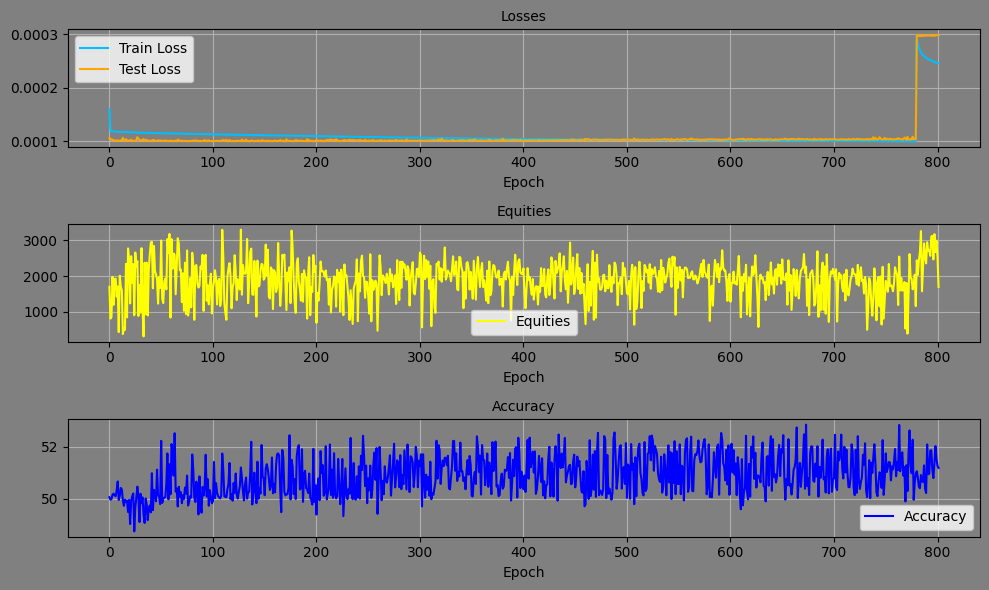

Epoch: 652, Equity: 2577.58, Accuracy: 51.22 train_losses: 0.000689136240415383, test_losses: 0.00029683535103686154, Duration: 0:00:06.273846


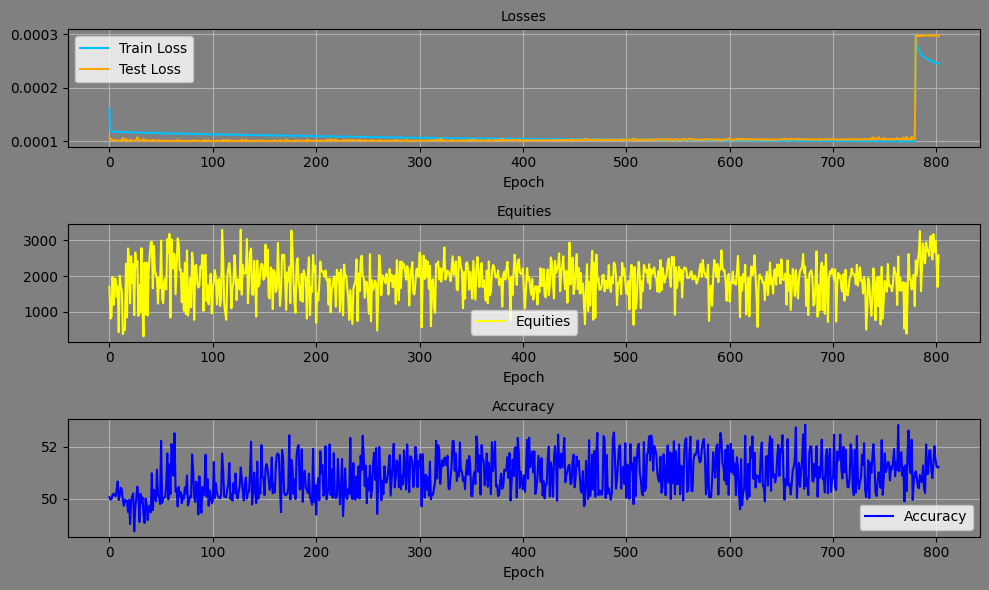

Epoch: 653, Equity: 2808.51, Accuracy: 52.52 train_losses: 0.0006867265113818364, test_losses: 0.0002972063375636935, Duration: 0:00:05.954854


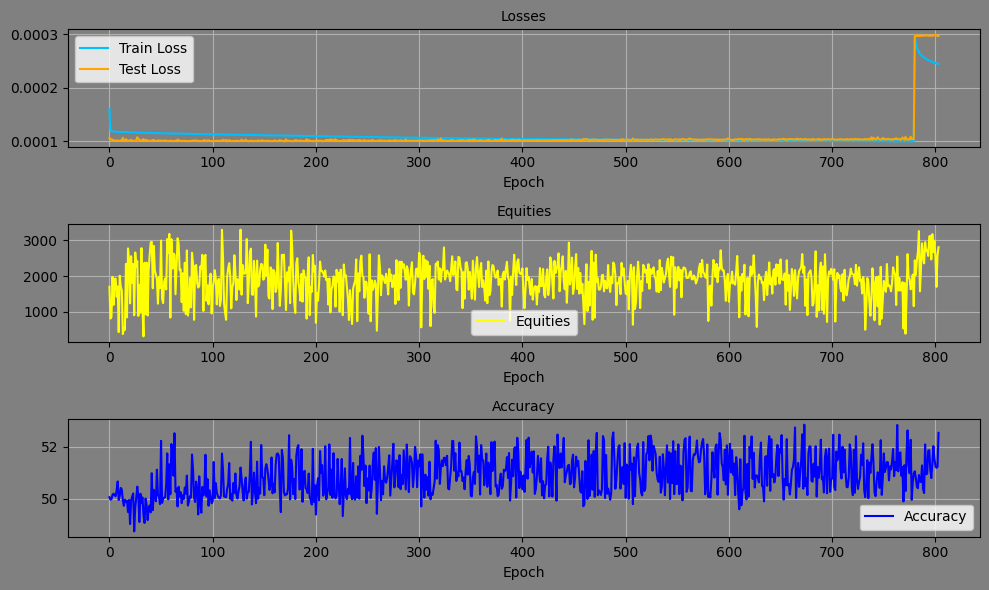

Epoch: 654, Equity: 2377.90, Accuracy: 51.30 train_losses: 0.00068575156597839, test_losses: 0.00029704184271395206, Duration: 0:00:06.575483


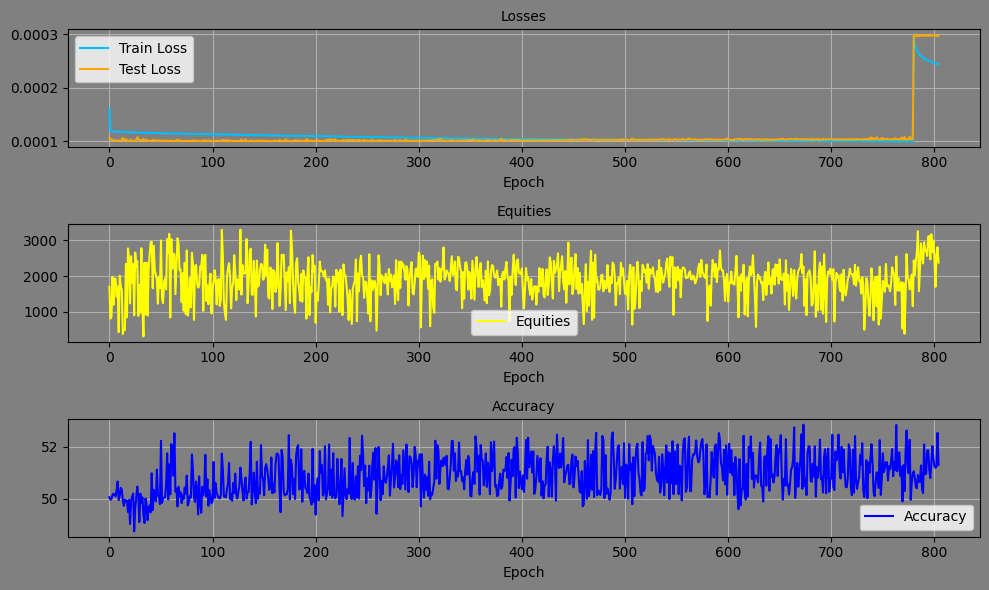

Epoch: 655, Equity: 2856.93, Accuracy: 51.16 train_losses: 0.0006834045324121953, test_losses: 0.00029751870897598565, Duration: 0:00:06.166443


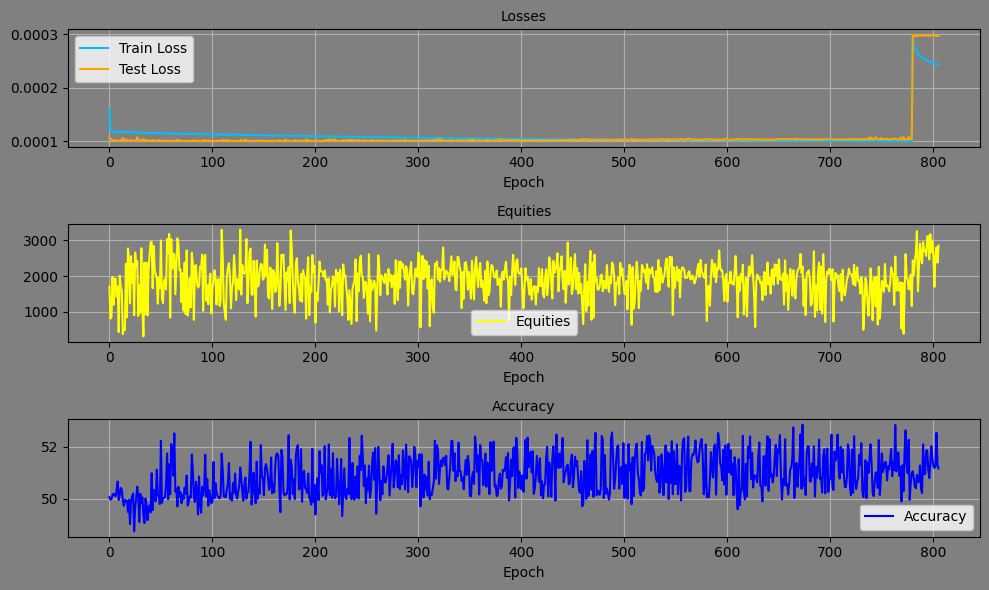

Epoch: 656, Equity: 2819.71, Accuracy: 51.46 train_losses: 0.0006822689867956375, test_losses: 0.0002969892229884863, Duration: 0:00:06.133874


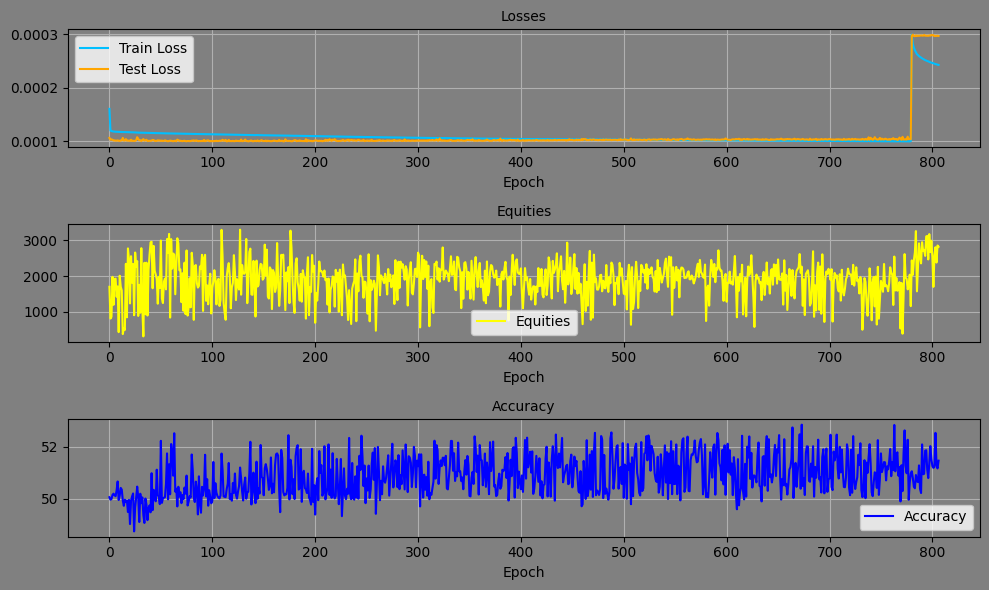

Epoch: 657, Equity: 2719.07, Accuracy: 51.73 train_losses: 0.0006805441311418848, test_losses: 0.00029823899967595935, Duration: 0:00:06.085816


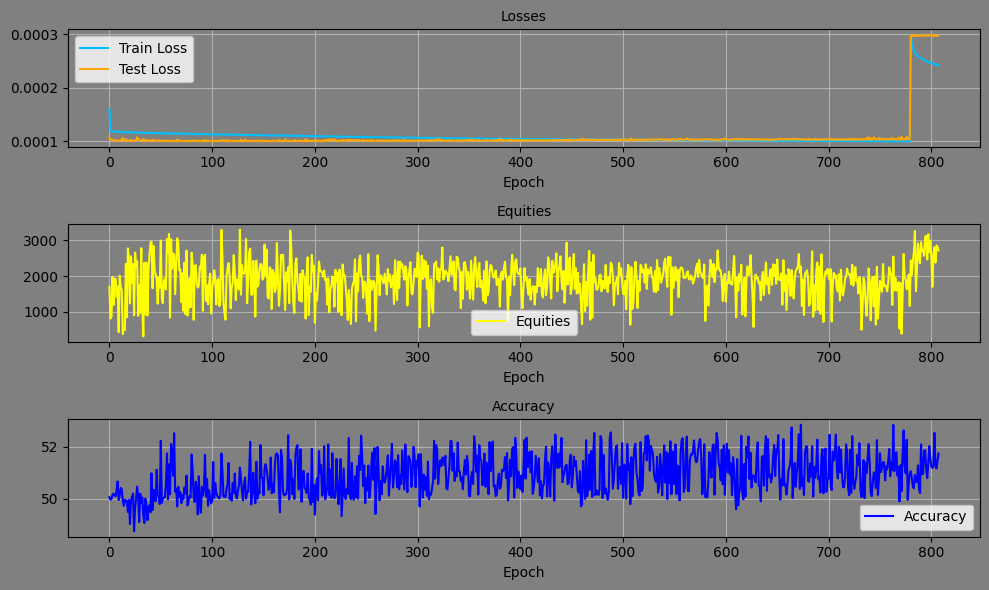

Epoch: 658, Equity: 2812.45, Accuracy: 51.54 train_losses: 0.0006784853058828352, test_losses: 0.0002981373982038349, Duration: 0:00:06.584459


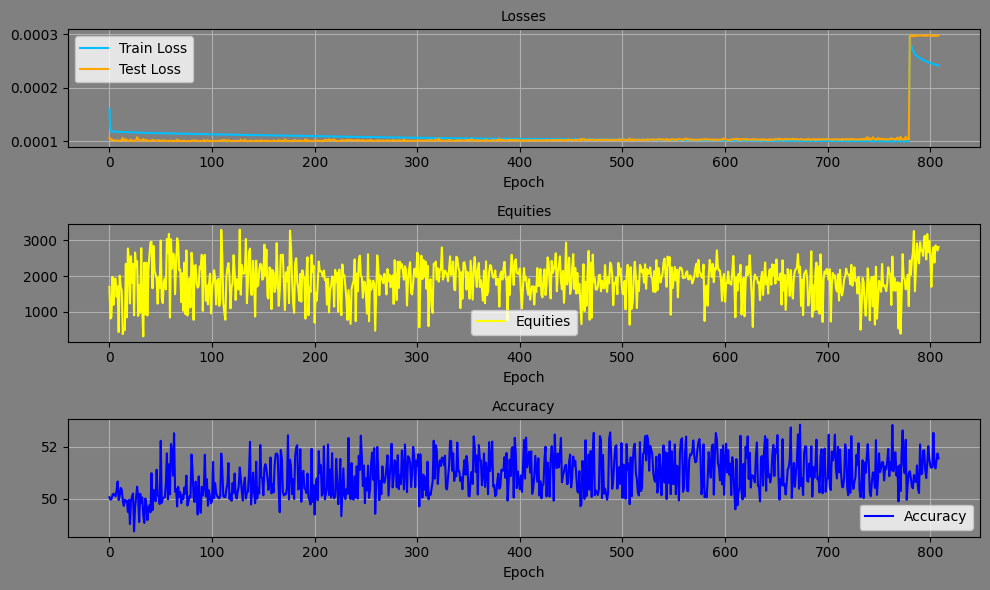

Epoch: 659, Equity: 2777.85, Accuracy: 51.72 train_losses: 0.0006778983474435771, test_losses: 0.00029727612854912877, Duration: 0:00:06.341192


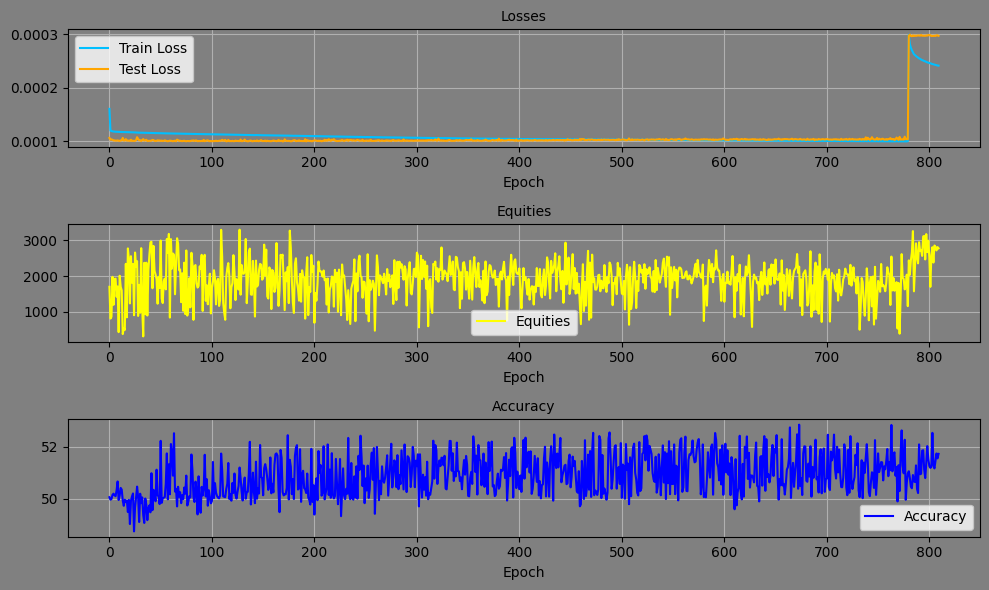

Epoch: 660, Equity: 3028.32, Accuracy: 51.37 train_losses: 0.0006755477517414703, test_losses: 0.00030002908897586167, Duration: 0:00:06.156054


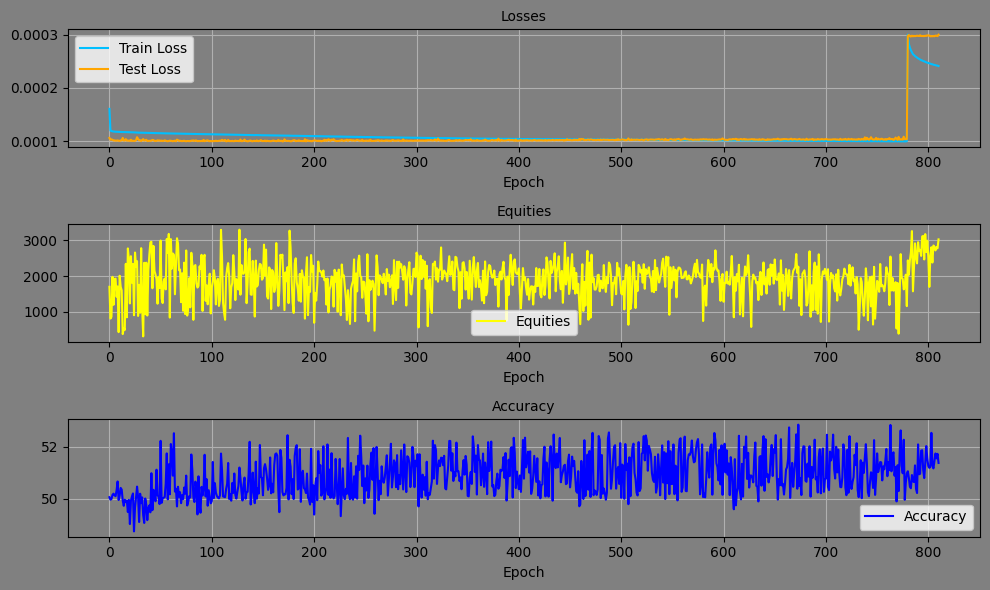

Epoch: 661, Equity: 3007.33, Accuracy: 51.42 train_losses: 0.0006743665665651307, test_losses: 0.00029797712340950966, Duration: 0:00:06.193038


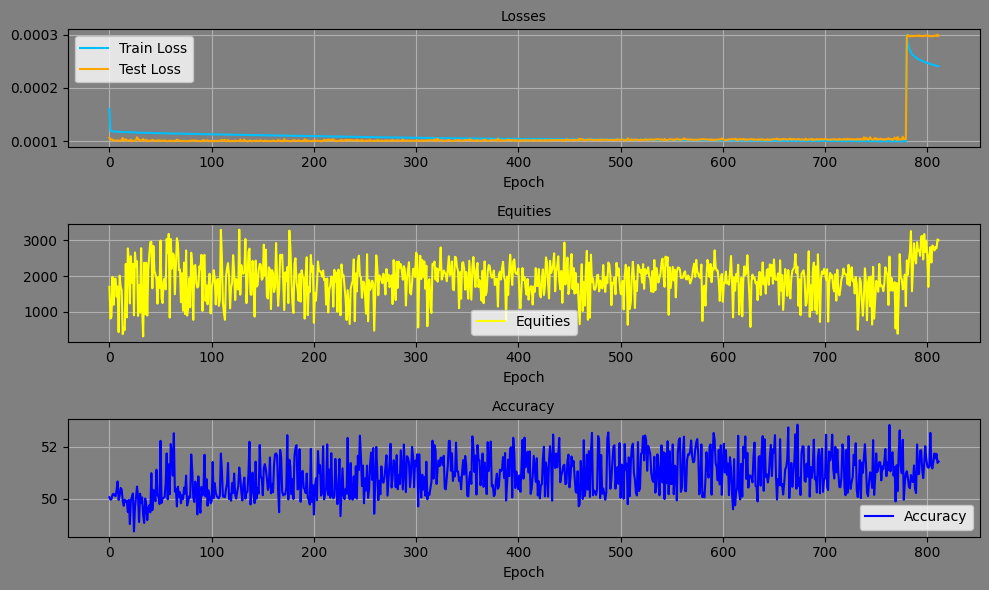

Epoch: 662, Equity: 2949.26, Accuracy: 51.29 train_losses: 0.0006725279420894314, test_losses: 0.000298823433695361, Duration: 0:00:06.277141


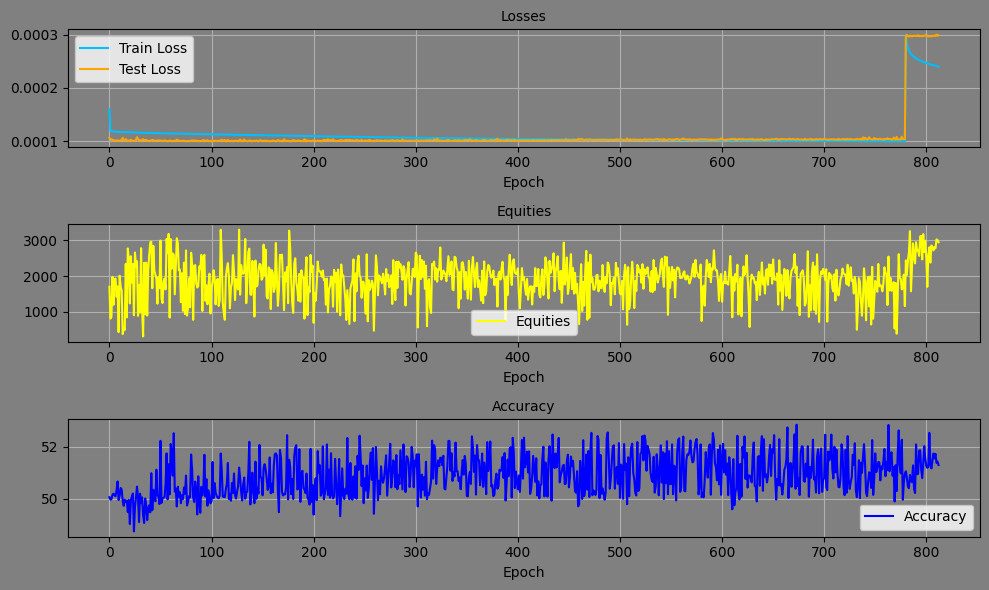

Epoch: 663, Equity: 3107.31, Accuracy: 52.78 train_losses: 0.0006719409163654917, test_losses: 0.0002981142606586218, Duration: 0:00:06.123788


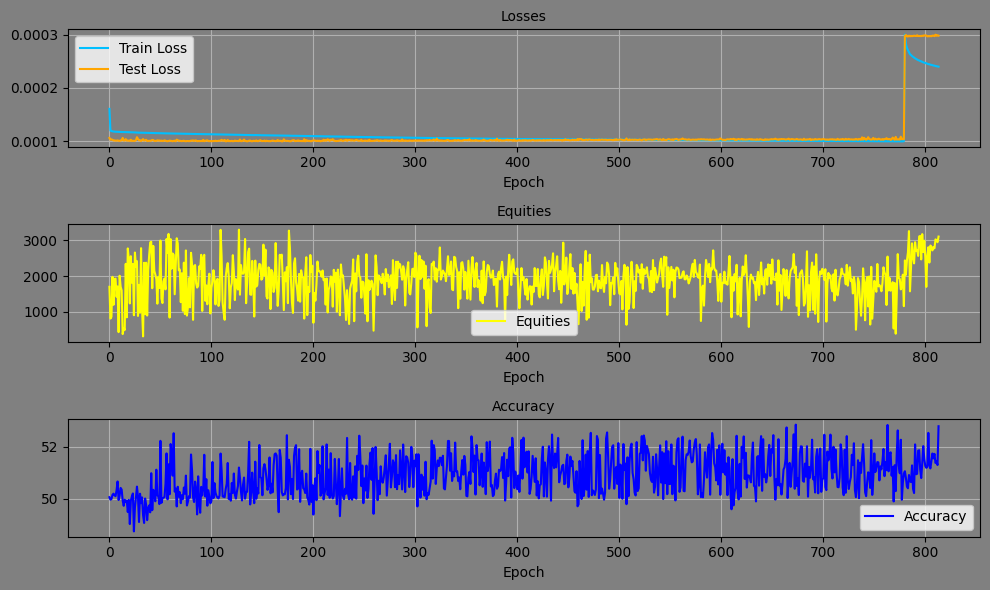

KeyboardInterrupt: 

In [ ]:
for epoch in range(epoch, num_epochs):

    # Track duration
    dt0_epoch = datetime.now()

    # Create mini batches
    mini_batches, seed = create_minibatches(X_train, Y_train, batch_size, seed, shuffle=True)

    train_losses_batch = []

    for X_train_batch, Y_train_batch in mini_batches:
        # Set train mode
        model.train()

        # Reset the gradients
        optimizer.zero_grad()

        # Forward propagation
        Y_hat_train = model(X_train_batch) # Shape: (batch_size, num_features)

        # Calculate loss (train)
        train_loss = criterion(Y_hat_train, Y_train_batch)

        # Backprop
        train_loss.backward()

        # Update optimizer
        optimizer.step()

        # Keep track of training losses
        train_losses_batch.append(train_loss.item())

    # Predict on test data
    with torch.no_grad():

        # Set evaluation mode
        model.eval()

        # # Forward propagation
        # Y_pred_test = model(X_test)

        # Forward propagation
        while True:
            try:
                # split the test set into chunks
                chunks = 16
                m = m_test // chunks
                
                for j in range(chunks+1):
                    Y_pred_test[m*j:m*j+m] = model(X_test[m*j:m*j+m])
                
                break

            except Exception as err:
                print(f"Chunks ({chunks}) err: {err}")
                chunks += 2

        # Calculate test loss
        test_loss = criterion(Y_pred_test, Y_test)

    # Convert 'Y_pred_test' to numpy
    Y_pred_test_cpu = Y_pred_test.detach().cpu().numpy()

    train_losses.append(np.mean(train_losses_batch))
    test_losses.append(test_loss.item())

    # ===================== Backtest =====================
    equities = []    # Store equity (account value) over time
    pos_size = 1000  # Fixed position size ($1000 per trade)
    equity = 1000    # Starting capital
    correct_pred = 0 # Initialize correct prediction

    actions = Y_pred_test_cpu[:, 0] > 0 # Get model's buy/sell predictions

    for i in range(len(X_test)-1):
        curr_open = backtest_opens[i]   # the price we enter at.
        curr_close = backtest_closes[i] # the price we exit at.
        curr_action = actions[i]        # the model’s signal (buy or sell).

        # Calculate percentage price change
        pct_change = (curr_close - curr_open) / curr_open

        # Profit or loss in dollars
        pnl = np.abs(pos_size * pct_change)

        # Update equity depending on action and price move
        if curr_action == 1:     # Long position (Buy side)
            if pct_change > 0:
                equity += pnl    # Price up → profit
                correct_pred += 1
            elif pct_change < 0:
                equity -= pnl    # Price down → loss

        elif curr_action == 0:   # Short position
            if pct_change > 0:
                equity -= pnl    # Price up → loss
            elif pct_change < 0:
                equity += pnl    # Price down → profit
                correct_pred += 1

        equities.append(equity) # Save current equity
    # ========================================================

    # Calculate percentage accuracy
    accuracy = correct_pred / len(X_test) * 100

    # Save final equity for each epoch
    equity_epochs.append(equity)
    accuracy_epochs.append(accuracy)

    print(f'Epoch: {epoch}, Equity: {equity:.2f}, Accuracy: {accuracy:.2f} train_losses: {train_losses[-1]}, test_losses: {test_losses[-1]}, Duration: {datetime.now() - dt0_epoch}')

    # Save training process
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'test_losses': test_losses,
        'equity_epochs': equity_epochs,
        'accuracy_epochs': accuracy_epochs,
        'seed': seed,
    }, 'training_process')

    if equity > 1200:
        torch.save(model.state_dict(), f"models/eq_{equity:.0f}_ep_{epoch}.pt")

    # Plot training process
    fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 6))
    scaler_testloss = MinMaxScaler(feature_range=(np.min(test_losses)-0.0000000001, np.max(test_losses)))

    # Plot Train Loss and Test Loss
    axs[0].set_title(f"Losses", fontsize=10)
    axs[0].plot(scaler_testloss.fit_transform(np.array(train_losses).reshape(-1,1)), label='Train Loss', color='deepskyblue')
    axs[0].plot(test_losses, label='Test Loss', color='orange')
    axs[0].set_xlabel("Epoch")
    axs[0].legend()
    axs[0].grid()
    # Plot Equities
    axs[1].set_title(f"Equities", fontsize=10)
    axs[1].plot(equity_epochs, label='Equities', color='yellow')
    axs[1].set_xlabel("Epoch")
    axs[1].legend()
    axs[1].grid()
    # Plot Accuracy
    axs[2].set_title(f"Accuracy", fontsize=10)
    axs[2].plot(accuracy_epochs, label='Accuracy', color='blue')
    axs[2].set_xlabel("Epoch")
    axs[2].legend()
    axs[2].grid()
    # Set background color and paper color
    fig.patch.set_facecolor(mcolors.to_hex('grey'))  # Set paper color
    for ax in axs.flat:
        ax.set_facecolor(mcolors.to_hex('grey'))  # Set bg color
    # Display
    plt.tight_layout()
    plt.savefig(f'training_process.png')
    plt.show()
    plt.close()